In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


from sympy import im
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import sklearn
from sklearn.preprocessing import StandardScaler

In [2]:
# Carico il dataset pinn_df
pinn_df = pd.read_csv(r"C:\Users\vinsc\Documents\DigitalTwin--PowerGrid\pinn_df.csv")
print(pinn_df.head())

              DateTime    House1    House2    House3    House4    House5  \
0  2023-09-18 00:00:00  0.353926  0.084078  0.303328  0.252427  0.386085   
1  2023-09-18 01:00:00  0.526320  0.057124  0.283109  0.226029  0.441071   
2  2023-09-18 02:00:00  0.536236  0.081743  0.280368  0.218727  0.484487   
3  2023-09-18 03:00:00  0.539307  0.085029  0.270917  0.206596  0.433297   
4  2023-09-18 04:00:00  0.553143  0.058800  0.265627  0.209230  0.420699   

    House11  Total_Load  Day_of_Year Day_Name  ...       SOC  Grid_Import  \
0  0.209238    1.769925          261   Monday  ...  0.500441          0.0   
1  0.176473    1.904744          261   Monday  ...  0.493281          0.0   
2  0.141122    1.941006          261   Monday  ...  0.490636          0.0   
3  0.121543    1.845225          261   Monday  ...  0.492616          0.0   
4  0.135342    1.829802          261   Monday  ...  0.496004          0.0   

   Grid_Export  Grid_Power  PV_to_Grid  Curtailment   Surplus   Deficit  \
0    

Epoch 000 | Train Loss: 3.933875 | Val Loss: 2.227515
Epoch 010 | Train Loss: 0.088595 | Val Loss: 0.194249
Epoch 020 | Train Loss: 0.060240 | Val Loss: 0.126642
Epoch 030 | Train Loss: 0.046145 | Val Loss: 0.142405
Epoch 040 | Train Loss: 0.036450 | Val Loss: 0.126209
Epoch 050 | Train Loss: 0.030172 | Val Loss: 0.107043
Epoch 060 | Train Loss: 0.025317 | Val Loss: 0.088879
Epoch 070 | Train Loss: 0.021378 | Val Loss: 0.091070
Epoch 080 | Train Loss: 0.018274 | Val Loss: 0.065845
Epoch 090 | Train Loss: 0.016042 | Val Loss: 0.073371
Epoch 100 | Train Loss: 0.014087 | Val Loss: 0.077635
Epoch 110 | Train Loss: 0.011650 | Val Loss: 0.061986
Epoch 120 | Train Loss: 0.010092 | Val Loss: 0.066873
Epoch 130 | Train Loss: 0.008994 | Val Loss: 0.056389
Epoch 140 | Train Loss: 0.008786 | Val Loss: 0.060916
Epoch 150 | Train Loss: 0.007919 | Val Loss: 0.070115
Epoch 160 | Train Loss: 0.006700 | Val Loss: 0.057810
Epoch 170 | Train Loss: 0.005439 | Val Loss: 0.091554
Epoch 180 | Train Loss: 0.00

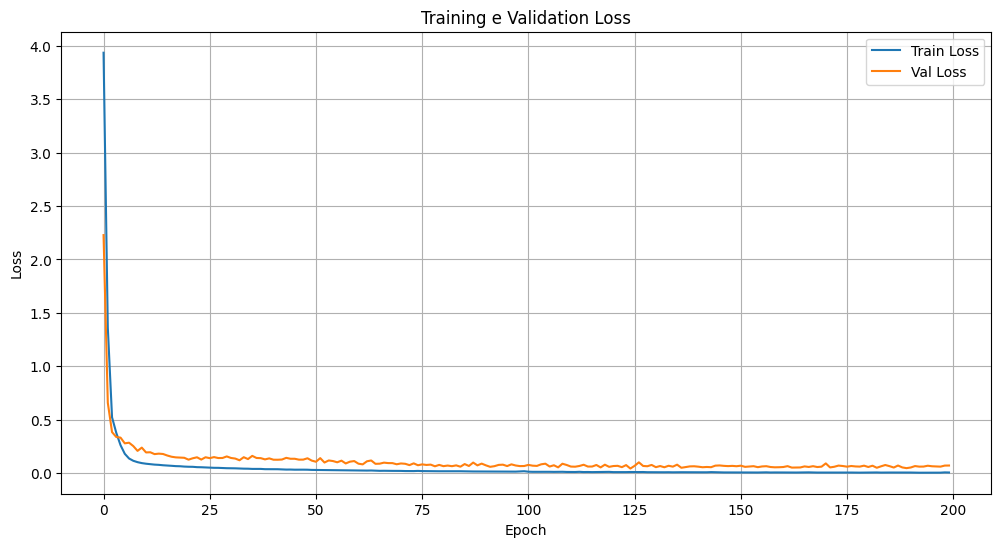


Test Loss finale: 0.054928


In [3]:
# ==============================
# 1) COPIA E PREPARAZIONE DEL DATASET
# ==============================

# facciamo una copia del dataset originale per non modificarlo direttamente
df = pinn_df.copy()

# convertiamo la colonna DateTime in vero formato datetime
df["DateTime"] = pd.to_datetime(df["DateTime"], errors="coerce")

# ordiniamo il dataset per tempo, perché la dinamica della batteria dipende dall'ordine temporale
df = df.sort_values("DateTime").reset_index(drop=True)

# ==============================
# 2) CREAZIONE DI FEATURE TEMPORALI CICLICHE
# ==============================

# estraiamo l'ora del giorno
df["hour"] = df["DateTime"].dt.hour

# estraiamo il giorno della settimana
df["weekday"] = df["DateTime"].dt.weekday

# estraiamo il mese
df["month"] = df["DateTime"].dt.month

# trasformiamo l'ora in feature cicliche
df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)

# trasformiamo il giorno della settimana in feature cicliche
df["weekday_sin"] = np.sin(2 * np.pi * df["weekday"] / 7)
df["weekday_cos"] = np.cos(2 * np.pi * df["weekday"] / 7)

# trasformiamo il mese in feature cicliche
df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

# ==============================
# 3) COSTRUZIONE DELLE VARIABILI PRECEDENTI
# ==============================

# prendiamo il SOC al passo precedente
df["SOC_prev"] = df["SOC"].shift(1)

# prendiamo l'energia della batteria al passo precedente
df["Battery_Energy_prev"] = df["Battery_Energy_kWh"].shift(1)

# prendiamo anche la potenza della batteria al passo precedente
df["Battery_Power_prev"] = df["Battery_Power"].shift(1)

# la prima riga avrà NaN perché non esiste t-1, quindi la eliminiamo
df = df.dropna().reset_index(drop=True)

# ==============================
# 4) SCELTA DELLE FEATURE DI INPUT
# ==============================

# input del modello:
# - produzione rinnovabile
# - carico totale
# - stato batteria al passo precedente
# - potenza precedente della batteria
# - feature temporali cicliche
feature_cols = [
    "Pv",
    "Total_Load",
    "SOC_prev",
    "Battery_Energy_prev",
    "Battery_Power_prev",
    "hour_sin",
    "hour_cos",
    "weekday_sin",
    "weekday_cos",
    "month_sin",
    "month_cos"
]

# ==============================
# 5) SCELTA DEI TARGET
# ==============================

# ora NON prediciamo più direttamente il SOC
# la rete predice solo i flussi di potenza
target_cols = [
    "PV_to_Battery",
    "Battery_to_Load",
    "Grid_Import",
    "Grid_Export"
]

# il SOC vero lo teniamo comunque per confrontarlo nella loss fisica
soc_target_col = "SOC"

# ==============================
# 6) SPLIT TEMPORALE TRAIN / VALID / TEST
# ==============================

n = len(df)

# split cronologico
train_end = int(n * 0.25)
val_end = int(n * 0.55)

train_df = df.iloc[:train_end].copy()
val_df = df.iloc[train_end:val_end].copy()
test_df = df.iloc[val_end:].copy()

# ==============================
# 7) NORMALIZZAZIONE DELLE FEATURE
# ==============================

scaler = StandardScaler()

# fit solo sul train
scaler.fit(train_df[feature_cols])

# trasformazione dei tre split
X_train = scaler.transform(train_df[feature_cols])
X_val = scaler.transform(val_df[feature_cols])
X_test = scaler.transform(test_df[feature_cols])

# target dei flussi
y_train = train_df[target_cols].values
y_val = val_df[target_cols].values
y_test = test_df[target_cols].values

# variabili fisiche aggiuntive, non scalate, utili nella loss
# inseriamo anche il SOC vero per confrontarlo col SOC ricostruito
phys_train = train_df[["Pv", "Total_Load", "SOC_prev", "Battery_Energy_prev", "SOC"]].values
phys_val = val_df[["Pv", "Total_Load", "SOC_prev", "Battery_Energy_prev", "SOC"]].values
phys_test = test_df[["Pv", "Total_Load", "SOC_prev", "Battery_Energy_prev", "SOC"]].values

# ==============================
# 8) CREAZIONE DEL DATASET PYTORCH
# ==============================

class MicrogridDataset(Dataset):
    
    # costruttore del dataset
    def __init__(self, X, y, phys):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
        self.phys = torch.tensor(phys, dtype=torch.float32)

    # numero di campioni
    def __len__(self):
        return len(self.X)

    # restituisce un campione
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx], self.phys[idx]

train_dataset = MicrogridDataset(X_train, y_train, phys_train)
val_dataset = MicrogridDataset(X_val, y_val, phys_val)
test_dataset = MicrogridDataset(X_test, y_test, phys_test)

# ==============================
# 9) CREAZIONE DEI DATALOADER
# ==============================

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

# ==============================
# 10) PARAMETRI FISICI DELLA BATTERIA
# ==============================

# capacità nominale batteria
E_max = 80.0

# efficienza di carica
eta_ch = 0.95

# efficienza di scarica
eta_dis = 0.95

# limiti SOC
SOC_min = 0.10
SOC_max = 0.90

# limiti energetici corrispondenti
E_min = SOC_min * E_max
E_max_use = SOC_max * E_max

# ==============================
# 11) DEFINIZIONE DELLA RETE NEURALE
# ==============================

class PINNMicrogrid(nn.Module):
    
    def __init__(self, input_dim):
        super().__init__()
        
        # backbone fully-connected
        self.backbone = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU()
        )
        
        # ora la testa finale produce 4 output, non più 5
        self.head = nn.Linear(64, 4)

    def forward(self, x):
        
        # passaggio nel backbone
        h = self.backbone(x)
        
        # output grezzi
        out = self.head(h)
        
        # separiamo i 4 output
        raw_pv_to_battery = out[:, 0:1]
        raw_battery_to_load = out[:, 1:2]
        raw_grid_import = out[:, 2:3]
        raw_grid_export = out[:, 3:4]
        
        # rendiamo i flussi non negativi
        pv_to_battery = torch.nn.functional.softplus(raw_pv_to_battery)
        battery_to_load = torch.nn.functional.softplus(raw_battery_to_load)
        grid_import = torch.nn.functional.softplus(raw_grid_import)
        grid_export = torch.nn.functional.softplus(raw_grid_export)
        
        # concateniamo i 4 flussi predetti
        return torch.cat(
            [pv_to_battery, battery_to_load, grid_import, grid_export],
            dim=1
        )

# creiamo il modello
model = PINNMicrogrid(input_dim=len(feature_cols))

# ==============================
# 12) OTTIMIZZATORE
# ==============================

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# loss MSE standard
mse_loss = nn.MSELoss()

# ==============================
# 13) FUNZIONE DI LOSS PHYSICS-INFORMED
# ==============================

def pinn_loss(y_pred, y_true, phys):
    
    # ------------------------------
    # OUTPUT PREDETTI DALLA RETE
    # ------------------------------
    pv_to_battery_pred = y_pred[:, 0]
    battery_to_load_pred = y_pred[:, 1]
    grid_import_pred = y_pred[:, 2]
    grid_export_pred = y_pred[:, 3]
    
    # ------------------------------
    # TARGET VERI
    # ------------------------------
    pv_to_battery_true = y_true[:, 0]
    battery_to_load_true = y_true[:, 1]
    grid_import_true = y_true[:, 2]
    grid_export_true = y_true[:, 3]
    
    # ------------------------------
    # VARIABILI FISICHE NOTE
    # ------------------------------
    pv_now = phys[:, 0]
    load_now = phys[:, 1]
    soc_prev = phys[:, 2]
    energy_prev = phys[:, 3]
    soc_true = phys[:, 4]
    
    # ------------------------------
    # 1) LOSS SUI DATI DEI FLUSSI
    # ------------------------------
    loss_data = mse_loss(y_pred, y_true)
    
    # ------------------------------
    # 2) BILANCIO ENERGETICO MICROGRID
    # ------------------------------
    lhs_energy = pv_now + grid_import_pred + battery_to_load_pred
    rhs_energy = load_now + pv_to_battery_pred + grid_export_pred
    loss_energy = torch.mean((lhs_energy - rhs_energy) ** 2)
    
    # ------------------------------
    # 3) DINAMICA BATTERIA
    # ------------------------------
    energy_next_raw = (
        energy_prev
        + eta_ch * pv_to_battery_pred
        - battery_to_load_pred / eta_dis
    )
    
    # imponiamo i limiti fisici sull'energia
    energy_next_clamped = torch.clamp(energy_next_raw, min=E_min, max=E_max_use)
    
    # ricaviamo il SOC dalla fisica
    soc_from_physics = energy_next_clamped / E_max
    
    # confrontiamo il SOC ricostruito fisicamente con il SOC vero
    loss_battery = torch.mean((soc_from_physics - soc_true) ** 2)
    
    # ------------------------------
    # 4) NIENTE CARICA E SCARICA CONTEMPORANEE
    # ------------------------------
    loss_no_simul_battery = torch.mean((pv_to_battery_pred * battery_to_load_pred) ** 2)
    
    # ------------------------------
    # 5) NIENTE IMPORT ED EXPORT CONTEMPORANEI
    # ------------------------------
    loss_no_simul_grid = torch.mean((grid_import_pred * grid_export_pred) ** 2)
    
    # ------------------------------
    # PESI DELLE COMPONENTI DELLA LOSS
    # ------------------------------
    lambda_data = 1.0
    lambda_energy = 1.0
    lambda_battery = 1.0
    lambda_no_batt = 0.1
    lambda_no_grid = 0.1
    
    # loss totale
    total_loss = (
        lambda_data * loss_data
        + lambda_energy * loss_energy
        + lambda_battery * loss_battery
        + lambda_no_batt * loss_no_simul_battery
        + lambda_no_grid * loss_no_simul_grid
    )
    
    # restituiamo loss totale e dettagli
    return total_loss, {
        "loss_data": loss_data.item(),
        "loss_energy": loss_energy.item(),
        "loss_battery": loss_battery.item(),
        "loss_no_simul_battery": loss_no_simul_battery.item(),
        "loss_no_simul_grid": loss_no_simul_grid.item()
    }

# ==============================
# 14) FUNZIONE DI VALIDAZIONE
# ==============================

def evaluate(model, loader):
    
    # modalità evaluation
    model.eval()
    
    losses = []
    
    # niente gradienti
    with torch.no_grad():
        for X_batch, y_batch, phys_batch in loader:
            y_pred = model(X_batch)
            loss, _ = pinn_loss(y_pred, y_batch, phys_batch)
            losses.append(loss.item())
    
    return np.mean(losses)

# ==============================
# 15) TRAINING LOOP
# ==============================

num_epochs = 200

train_losses = []
val_losses = []

for epoch in range(num_epochs):
    
    model.train()
    epoch_losses = []
    
    for X_batch, y_batch, phys_batch in train_loader:
        
        # azzeriamo i gradienti
        optimizer.zero_grad()
        
        # predizione
        y_pred = model(X_batch)
        
        # calcolo loss
        loss, loss_dict = pinn_loss(y_pred, y_batch, phys_batch)
        
        # backward
        loss.backward()
        
        # update pesi
        optimizer.step()
        
        epoch_losses.append(loss.item())
    
    train_loss = np.mean(epoch_losses)
    val_loss = evaluate(model, val_loader)
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    
    if epoch % 10 == 0:
        print(
            f"Epoch {epoch:03d} | "
            f"Train Loss: {train_loss:.6f} | "
            f"Val Loss: {val_loss:.6f}"
        )

# ==============================
# 16) GRAFICO DELLE LOSS
# ==============================

plt.figure(figsize=(12, 6))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training e Validation Loss")
plt.legend()
plt.grid()
plt.show()

# ==============================
# 17) VALUTAZIONE SU TEST
# ==============================

test_loss = evaluate(model, test_loader)
print(f"\nTest Loss finale: {test_loss:.6f}")

# ==============================
# 18) PREDIZIONI SUL TEST SET
# ==============================

model.eval()
pred_list = []

with torch.no_grad():
    for X_batch, y_batch, phys_batch in test_loader:
        y_pred = model(X_batch)
        pred_list.append(y_pred.numpy())

pred_array = np.vstack(pred_list)

# dataframe finale predizioni
pred_df = test_df[["DateTime"]].copy()

# flussi predetti
pred_df["PV_to_Battery_pred"] = pred_array[:, 0]
pred_df["Battery_to_Load_pred"] = pred_array[:, 1]
pred_df["Grid_Import_pred"] = pred_array[:, 2]
pred_df["Grid_Export_pred"] = pred_array[:, 3]

# aggiungiamo i flussi veri
pred_df["PV_to_Battery_true"] = test_df["PV_to_Battery"].values
pred_df["Battery_to_Load_true"] = test_df["Battery_to_Load"].values
pred_df["Grid_Import_true"] = test_df["Grid_Import"].values
pred_df["Grid_Export_true"] = test_df["Grid_Export"].values

# ==============================
# 19) RICOSTRUZIONE DEL SOC PREDDETTO DALLA FISICA
# ==============================

# il SOC predetto non viene più emesso direttamente dalla rete
# lo ricostruiamo dai flussi predetti e dall'energia precedente
energy_prev_test = test_df["Battery_Energy_prev"].values

energy_pred = (
    energy_prev_test
    + eta_ch * pred_df["PV_to_Battery_pred"].values
    - pred_df["Battery_to_Load_pred"].values / eta_dis
)

# applichiamo i limiti fisici
energy_pred = np.clip(energy_pred, E_min, E_max_use)

# SOC ricostruito
pred_df["SOC_pred"] = energy_pred / E_max

# SOC vero per confronto
pred_df["SOC_true"] = test_df["SOC"].values

# se vuoi, puoi stampare le prime righe
# print(pred_df.head())

===== METRICHE SUL TEST SET =====

PV_to_Battery
MAE  = 0.034489
RMSE = 0.152620
R²   = 0.949949

Battery_to_Load
MAE  = 0.060624
RMSE = 0.165748
R²   = 0.944798

Grid_Import
MAE  = 0.098701
RMSE = 0.221546
R²   = 0.977543

Grid_Export
MAE  = 0.024956
RMSE = 0.173576
R²   = 0.875735

SOC
MAE  = 0.000567
RMSE = 0.001758
R²   = 0.999950

===== CONTROLLO FISICO DELLE PREVISIONI =====
Residuo bilancio energetico predetto:
count    7129.000000
mean       -0.048477
std         0.141148
min        -0.829052
25%        -0.102782
50%        -0.021423
75%         0.019096
max         1.324711
dtype: float64
Errore assoluto medio: 0.09619660673665105
Errore assoluto massimo: 1.3247105252677835

SOC predetto:
min = 0.1
max = 0.9

Prodotto carica*scarica (deve stare basso):
count    7.129000e+03
mean     6.486183e-04
std      1.453216e-03
min      1.720100e-19
25%      3.564420e-07
50%      2.210049e-05
75%      4.950340e-04
max      1.137290e-02
dtype: float64

Prodotto import*export (deve stare b

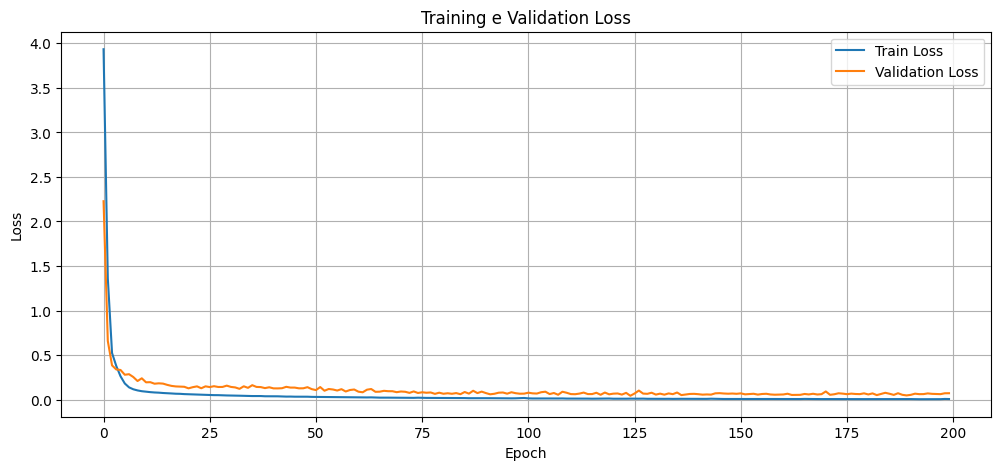

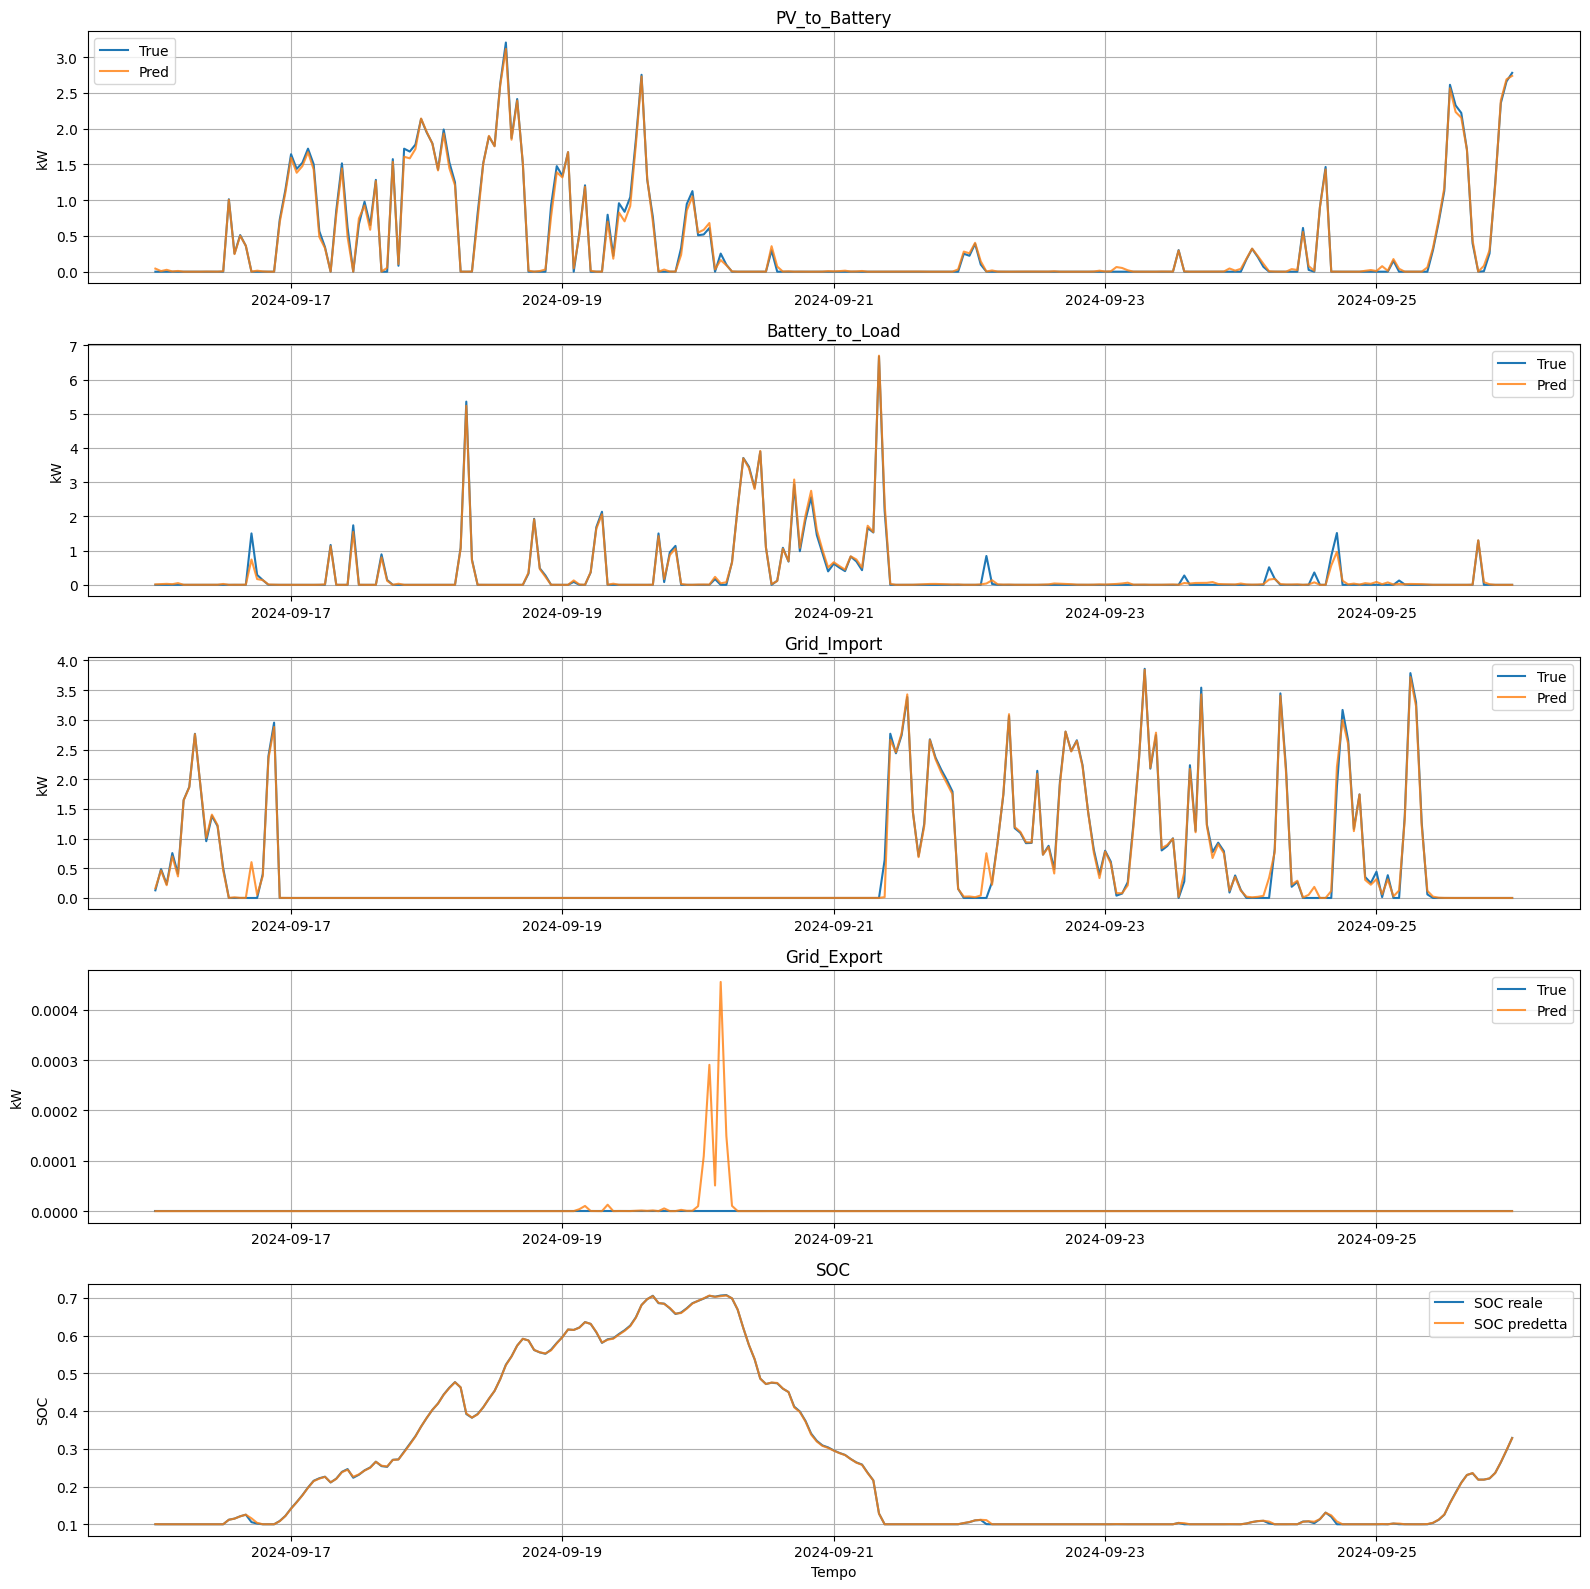

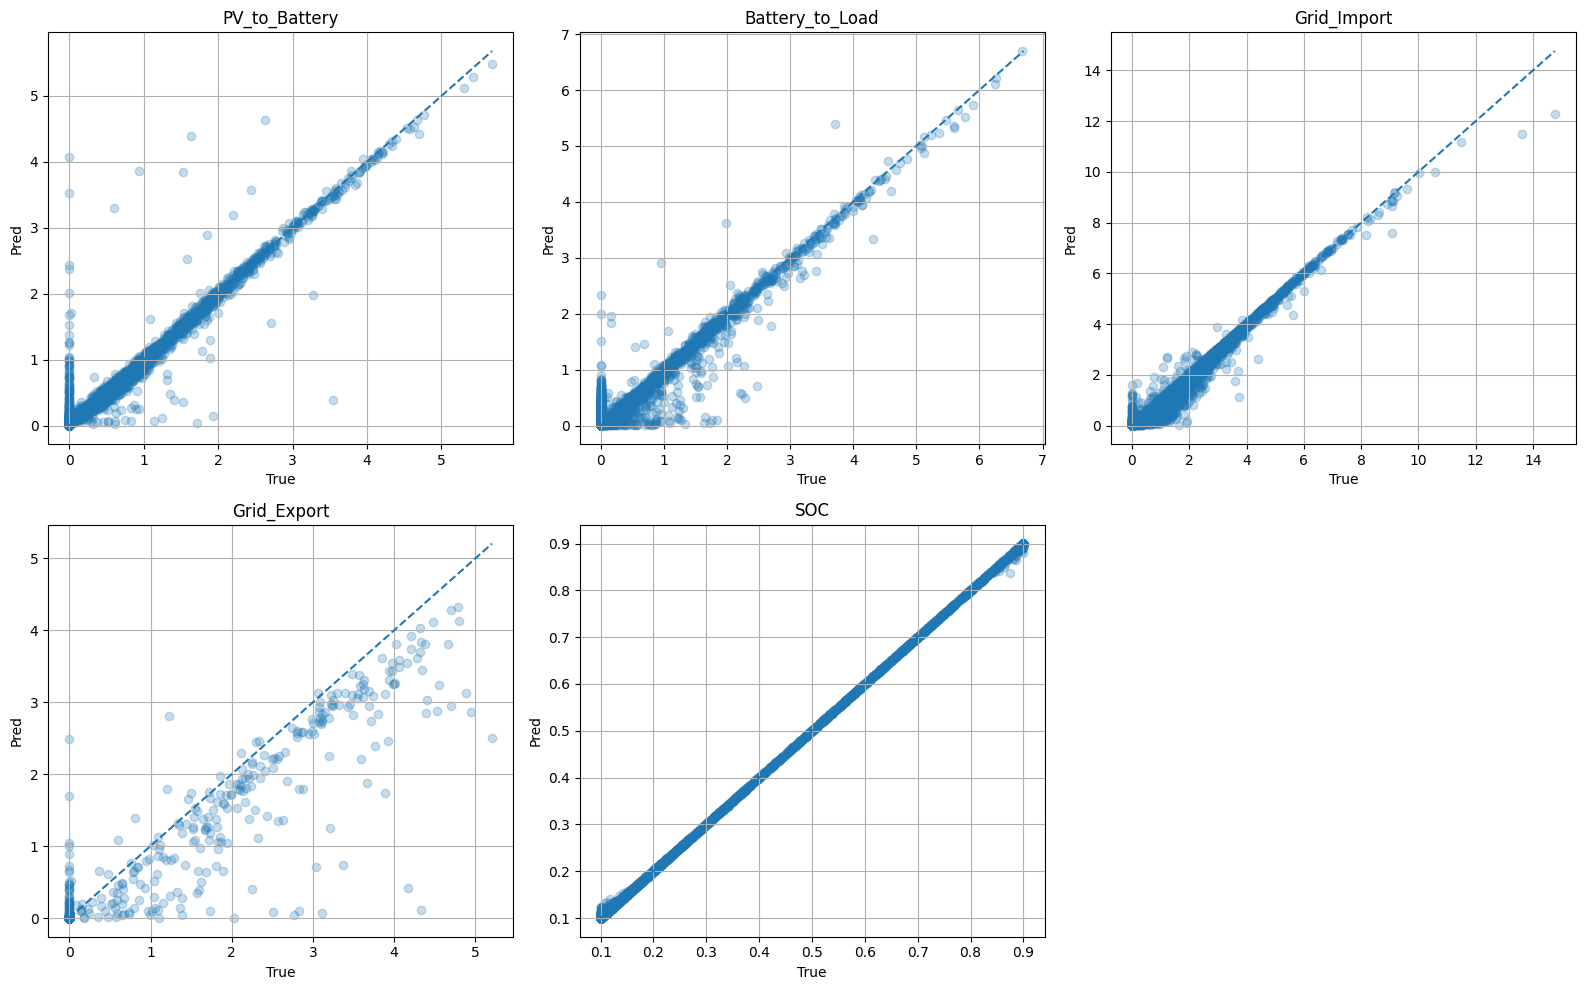

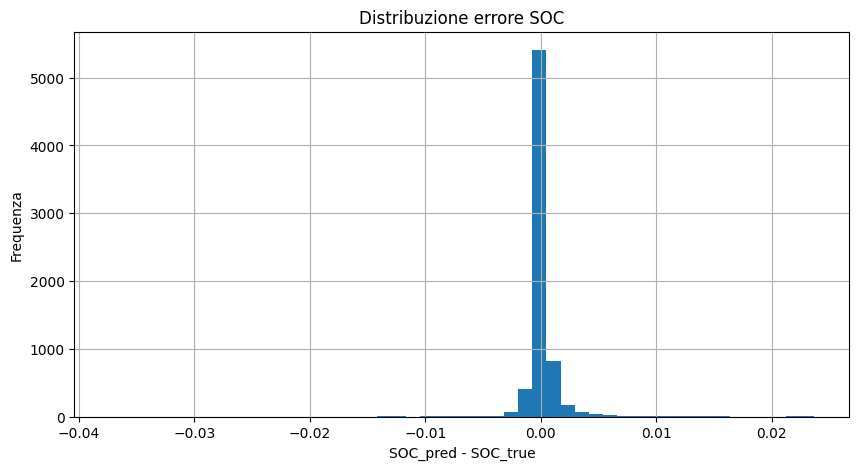

In [5]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# =========================
# 1) COPIA E PREPARAZIONE
# =========================

plot_df = pred_df.copy()
plot_df["DateTime"] = pd.to_datetime(plot_df["DateTime"], errors="coerce")
plot_df = plot_df.sort_values("DateTime").reset_index(drop=True)

# =========================
# 2) METRICHE NUMERICHE
# =========================

def print_metrics(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    
    print(f"\n{name}")
    print(f"MAE  = {mae:.6f}")
    print(f"RMSE = {rmse:.6f}")
    print(f"R²   = {r2:.6f}")

print("===== METRICHE SUL TEST SET =====")

print_metrics(
    "PV_to_Battery",
    plot_df["PV_to_Battery_true"].values,
    plot_df["PV_to_Battery_pred"].values
)

print_metrics(
    "Battery_to_Load",
    plot_df["Battery_to_Load_true"].values,
    plot_df["Battery_to_Load_pred"].values
)

print_metrics(
    "Grid_Import",
    plot_df["Grid_Import_true"].values,
    plot_df["Grid_Import_pred"].values
)

print_metrics(
    "Grid_Export",
    plot_df["Grid_Export_true"].values,
    plot_df["Grid_Export_pred"].values
)

print_metrics(
    "SOC",
    plot_df["SOC_true"].values,
    plot_df["SOC_pred"].values
)

# =========================
# 3) CONTROLLI DI SANITÀ FISICA
# =========================

# Se il modello è sensato, questi residui devono essere piccoli
# Usiamo i flussi predetti e il SOC ricostruito

# servono anche le colonne originali del test set
test_check = test_df.copy().reset_index(drop=True)

# bilancio energetico con i valori predetti
lhs_pred = (
    test_check["Pv"].values
    + plot_df["Grid_Import_pred"].values
    + plot_df["Battery_to_Load_pred"].values
)

rhs_pred = (
    test_check["Total_Load"].values
    + plot_df["PV_to_Battery_pred"].values
    + plot_df["Grid_Export_pred"].values
)

energy_residual = lhs_pred - rhs_pred

print("\n===== CONTROLLO FISICO DELLE PREVISIONI =====")
print("Residuo bilancio energetico predetto:")
print(pd.Series(energy_residual).describe())
print("Errore assoluto medio:", np.mean(np.abs(energy_residual)))
print("Errore assoluto massimo:", np.max(np.abs(energy_residual)))

# controllo vincoli fisici SOC
print("\nSOC predetto:")
print("min =", plot_df["SOC_pred"].min())
print("max =", plot_df["SOC_pred"].max())

# controllo simultaneità carica/scarica
simul_batt = plot_df["PV_to_Battery_pred"].values * plot_df["Battery_to_Load_pred"].values
print("\nProdotto carica*scarica (deve stare basso):")
print(pd.Series(simul_batt).describe())

# controllo simultaneità import/export
simul_grid = plot_df["Grid_Import_pred"].values * plot_df["Grid_Export_pred"].values
print("\nProdotto import*export (deve stare basso):")
print(pd.Series(simul_grid).describe())

# =========================
# 4) GRAFICO LOSS TRAIN/VAL
# =========================

plt.figure(figsize=(12, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training e Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

# =========================
# 5) GRAFICO TEMPORALE SU UNA FINESTRA
# =========================

# scegli una finestra temporale per vedere meglio il comportamento
start = plot_df["DateTime"].iloc[0]
end = start + pd.Timedelta(days=10)

window_df = plot_df[
    (plot_df["DateTime"] >= start) &
    (plot_df["DateTime"] <= end)
].copy()

plt.figure(figsize=(16, 16))

# PV_to_Battery
plt.subplot(5, 1, 1)
plt.plot(window_df["DateTime"], window_df["PV_to_Battery_true"], label="True")
plt.plot(window_df["DateTime"], window_df["PV_to_Battery_pred"], label="Pred", alpha=0.8)
plt.title("PV_to_Battery")
plt.ylabel("kW")
plt.legend()
plt.grid(True)

# Battery_to_Load
plt.subplot(5, 1, 2)
plt.plot(window_df["DateTime"], window_df["Battery_to_Load_true"], label="True")
plt.plot(window_df["DateTime"], window_df["Battery_to_Load_pred"], label="Pred", alpha=0.8)
plt.title("Battery_to_Load")
plt.ylabel("kW")
plt.legend()
plt.grid(True)

# Grid_Import
plt.subplot(5, 1, 3)
plt.plot(window_df["DateTime"], window_df["Grid_Import_true"], label="True")
plt.plot(window_df["DateTime"], window_df["Grid_Import_pred"], label="Pred", alpha=0.8)
plt.title("Grid_Import")
plt.ylabel("kW")
plt.legend()
plt.grid(True)

# Grid_Export
plt.subplot(5, 1, 4)
plt.plot(window_df["DateTime"], window_df["Grid_Export_true"], label="True")
plt.plot(window_df["DateTime"], window_df["Grid_Export_pred"], label="Pred", alpha=0.8)
plt.title("Grid_Export")
plt.ylabel("kW")
plt.legend()
plt.grid(True)

# SOC
plt.subplot(5, 1, 5)
plt.plot(window_df["DateTime"], window_df["SOC_true"], label="SOC reale")
plt.plot(window_df["DateTime"], window_df["SOC_pred"], label="SOC predetta", alpha=0.8)
plt.title("SOC")
plt.xlabel("Tempo")
plt.ylabel("SOC")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# =========================
# 6) SCATTER TRUE VS PRED
# =========================

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

pairs = [
    ("PV_to_Battery_true", "PV_to_Battery_pred", "PV_to_Battery"),
    ("Battery_to_Load_true", "Battery_to_Load_pred", "Battery_to_Load"),
    ("Grid_Import_true", "Grid_Import_pred", "Grid_Import"),
    ("Grid_Export_true", "Grid_Export_pred", "Grid_Export"),
    ("SOC_true", "SOC_pred", "SOC"),
]

for i, (true_col, pred_col, title) in enumerate(pairs):
    y_true = plot_df[true_col].values
    y_pred = plot_df[pred_col].values
    
    axes[i].scatter(y_true, y_pred, alpha=0.25)
    mn = min(y_true.min(), y_pred.min())
    mx = max(y_true.max(), y_pred.max())
    axes[i].plot([mn, mx], [mn, mx], linestyle="--")
    axes[i].set_title(title)
    axes[i].set_xlabel("True")
    axes[i].set_ylabel("Pred")
    axes[i].grid(True)

# togli ultimo asse vuoto
fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

# =========================
# 7) ISTOGRAMMA ERRORE SOC
# =========================

soc_error = plot_df["SOC_pred"] - plot_df["SOC_true"]

plt.figure(figsize=(10, 5))
plt.hist(soc_error, bins=50)
plt.xlabel("SOC_pred - SOC_true")
plt.ylabel("Frequenza")
plt.title("Distribuzione errore SOC")
plt.grid(True)
plt.show()